# Example 5.6

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def tridisolve(a, b, c, d):
    """
    Solves a tridiagonal linear system using the Thomas algorithm

    a : subdiagonal (length n-1)
    b : main diagonal (length n)
    c : superdiagonal (length n-1)
    d : right-hand side vector (length n)
    """
    n = len(b)
    cp = np.zeros(n-1)
    dp = np.zeros(n)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n-1):
        denom = b[i] - a[i-1] * cp[i-1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i-1] * dp[i-1]) / denom

    dp[n-1] = (d[n-1] - a[n-2] * dp[n-2]) / (b[n-1] - a[n-2] * cp[n-2])

    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in reversed(range(n-1)):
        x[i] = dp[i] - cp[i] * x[i+1]

    return x


def laplace(N, M, Tw, errmax=1e-3, maxit=100):
    """
    Function that solves the Laplace equation of Example 5.1
    using finite-difference methods

    N : number of nodes in the x direction, x in [0, 1]
    M : number of nodes in the y direction, y in [0, 1]
    Tw : temperature on the lower boundary of the square [0,1] x [0,1]
    errmax : maximum allowed error
    maxit : maximum number of iterations allowed

    Returns
    -------
    T : (N+1) x (M+1) matrix with temperature values
    err : final maximum error
    iter : number of iterations performed
    lapmax : maximum value of the discrete Laplacian (diagnostic)
    """

    # Common parameters and initial temperature field
    dx = 1.0 / N
    dy = 1.0 / M
    beta2 = (dx / dy) ** 2

    a = -np.ones(N - 1)
    b = 2.0 * (1.0 + beta2) * np.ones(N - 1)
    c = -np.ones(N - 1)
    r = np.zeros(N - 1)

    T = np.zeros((N + 1, M + 1))

    # Boundary conditions
    T[:, 0] = Tw        # bottom boundary
    T[:, -1] = 0.0      # top boundary
    T[0, :] = 0.0       # left boundary
    T[-1, :] = 0.0      # right boundary

    # Iteration loop
    err = 1.0
    iter = 0

    while err > errmax and iter < maxit:
        Told = T.copy()

        # Row-sweep loop
        for j in range(1, M):
            for i in range(N - 1):
                r[i] = beta2 * (T[i + 1, j - 1] + Told[i + 1, j + 1])

            v = tridisolve(a, b, c, r)
            T[1:N, j] = v

        err = np.linalg.norm(T - Told) / np.linalg.norm(T)
        iter += 1

    # Maximum discrete Laplacian (optional diagnostic)
    lapmax = np.max(np.abs(T[2:, 1:-1] + T[:-2, 1:-1] +
                            T[1:-1, 2:] + T[1:-1, :-2] -
                            4 * T[1:-1, 1:-1]))

    # Results visualization
    x = np.linspace(0.0, 1.0, N + 1)
    y = np.linspace(0.0, 1.0, M + 1)

    plt.contourf(x, y, T.T, cmap="jet")
    plt.colorbar()
    plt.title("Solution of the Laplace equation")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("square")
    plt.grid(True)
    filename = 'Figure_5_9.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return T, err, iter, lapmax

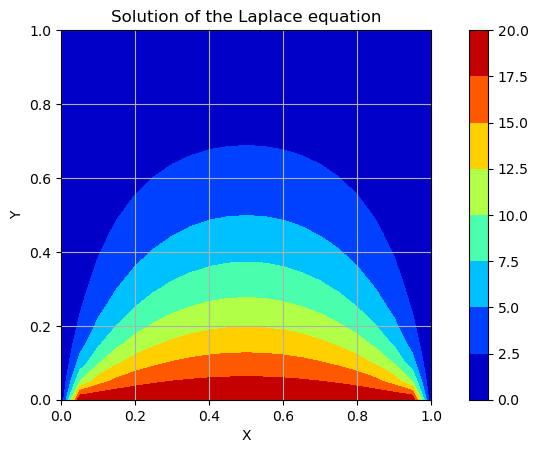

109
0.0015603234309189418


In [2]:
# calling the script and generating Figure 5.9
T, err, iters, lapmax = laplace(
    N=20,
    M=20,
    Tw=20.0,
    errmax=1e-4,
    maxit=200
)

print(iters)
print(lapmax)
